# Ising Model: Relaxation to Equilibrium

When a Monte Carlo simulation starts from an arbitrary (e.g. random) configuration, the system is far from its thermal equilibrium state. During the initial **relaxation** (or *thermalization*) transient, observables drift systematically as the Markov chain moves toward the stationary distribution. Only after the chain has forgotten its starting point — after the **relaxation time** $\tau_\text{relax}$ has elapsed — do the samples represent genuine thermal fluctuations that can be used for measurement.

This notebook quantifies relaxation to equilibrium for the 2D Ising model by comparing three update schemes:

- **Random-site Metropolis** — one randomly chosen spin is proposed per step.
- **Checkerboard Metropolis** — sites are swept in a fixed checkerboard pattern, eliminating the random-site overhead.
- **Wolff cluster** — a whole correlated cluster is flipped in one move, dramatically reducing autocorrelation near $T_c$.

All three algorithms start from the same deliberately unfavorable initial condition: a fully random spin configuration with no warm-up. The analysis covers four temperature slices: deep in the ordered phase ($0.5\,T_c \approx 1.13$), just below $T_c$, at the Onsager critical point $T_c = 2/\ln(1 + \sqrt{2}) \approx 2.269$ [[1]](#Bibliography), and above $T_c$. The critical point is where critical slowing down makes relaxation slowest and the contrast between algorithms most pronounced.

The notebook has four parts:
1. **Visual demonstration** — $|M|$ trajectories make the transient and its temperature-dependence immediately visible.
2. **Two-start relaxation time** — a threshold-crossing estimator on two-start convergence extracts $\hat{\tau}_\text{relax}$, the time for the chain to forget its initial condition.
3. **Integrated autocorrelation time** — $\tau_\text{int}$ measures equilibrium memory and controls the effective sample size once in equilibrium.
4. **Interpretation** — both metrics are connected to critical slowing down, algorithm work normalisation, and the distinction between thermalization and statistical independence.

In [1]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np

from models.ising_model import IsingSimulation
from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.physics_helpers import calculate_autocorr, estimate_relaxation_time_two_start

TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
L = 64
N_STEPS = 1000
TEMPS = [0.5 * TC_ISING, 0.8 * TC_ISING, TC_ISING, 1.2 * TC_ISING]
TEMP_LABELS = ['Deep below $T_c$', 'Below $T_c$', 'At $T_c$', 'Above $T_c$']
UPDATES = ['random', 'checkerboard', 'wolff']
UPDATE_LABELS = {
    'random': 'Random-site Metropolis',
    'checkerboard': 'Checkerboard Metropolis',
    'wolff': 'Wolff cluster',
}
PALETTE = {'random': '#4878CF', 'checkerboard': '#6ACC65', 'wolff': '#D65F5F'}

# Robust relaxation analysis settings (used at/near criticality)
SEEDS = np.array([11, 22, 33, 44, 55, 66, 77, 88, 99, 111], dtype=int)
INIT_STATES = ['random', 'ordered']
MAX_STEPS_FACTOR = 4

CACHE_PATH = '../results/ising/ising_autocorrelation_multiseed_analysis.npz'

print(f'Exact Onsager T_c = {TC_ISING:.6f}')
print(f'Notebook cache path: {CACHE_PATH}')
print(f'L = {L}, base N_STEPS = {N_STEPS}, seeds = {len(SEEDS)}')


Exact Onsager T_c = 2.269185
Notebook cache path: ../results/ising/ising_autocorrelation_multiseed_analysis.npz
L = 64, base N_STEPS = 1000, seeds = 10


## Load or compute trajectories

If a cached trajectory file exists in `../results/ising/ising_autocorrelation_analysis.npz`, the notebook reuses it directly. Otherwise it runs the four temperature slices inline and saves the resulting $|M|$ time series for later reads. This keeps the notebook self-contained even though there is no separate batch script for this specific figure yet.

In [2]:
max_steps = N_STEPS * MAX_STEPS_FACTOR
n_temp = len(TEMPS)
n_upd = len(UPDATES)
n_seed = len(SEEDS)
n_init = len(INIT_STATES)
wolff_idx = UPDATES.index('wolff')

needs_recompute = True
if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH, allow_pickle=False)
    required = {
        'temperatures',
        'updates',
        'seeds',
        'init_states',
        'magnetization_traces_full',
        'steps_used',
        'wolff_cluster_sizes',   # new field — forces rebuild of old caches
    }
    if required.issubset(set(data.files)):
        magnetization_traces_full = data['magnetization_traces_full']
        steps_used = data['steps_used']
        wolff_cluster_sizes = data['wolff_cluster_sizes']
        if int(magnetization_traces_full.shape[0]) == n_temp:
            needs_recompute = False
        print(
            f'Loaded cached trajectories from {CACHE_PATH}: '
            f'shape={magnetization_traces_full.shape}.'
        )

if needs_recompute:
    print('Compatible cache not found. Running multi-seed simulations and saving the result...')
    magnetization_traces_full = np.full((n_temp, n_upd, n_seed, n_init, max_steps), np.nan, dtype=float)
    steps_used = np.zeros((n_temp, n_upd, n_seed, n_init), dtype=int)
    # Wolff cluster sizes are only meaningful for the Wolff update; shape mirrors the full array.
    wolff_cluster_sizes = np.zeros((n_temp, n_seed, n_init, max_steps), dtype=int)

    for i, temperature in enumerate(TEMPS):
        for j, update in enumerate(UPDATES):
            for s_idx, seed in enumerate(SEEDS):
                for init_idx, init_state in enumerate(INIT_STATES):
                    is_critical_local = TEMP_LABELS[i] == 'At $T_c$' and update in {'random', 'checkerboard'}
                    n_run = max_steps if is_critical_local else N_STEPS

                    sim = IsingSimulation(size=L, temp=temperature, update=update, seed=int(seed))
                    if init_state == 'ordered':
                        sim.spins = np.ones((L, L), dtype=np.int8)

                    if update == 'wolff':
                        mags, _, csizes = sim.run_with_cluster_sizes(n_steps=n_run)
                        wolff_cluster_sizes[i, s_idx, init_idx, :n_run] = csizes
                    else:
                        mags, _ = sim.run(n_steps=n_run)

                    magnetization_traces_full[i, j, s_idx, init_idx, :n_run] = np.asarray(mags, dtype=float)
                    steps_used[i, j, s_idx, init_idx] = n_run

        print(
            f'  T={temperature:.3f}: all updates, {n_seed * n_init} trajectories each complete',
            flush=True,
        )

    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    np.savez(
        CACHE_PATH,
        temperatures=np.asarray(TEMPS, dtype=float),
        temp_labels=np.asarray(TEMP_LABELS),
        updates=np.asarray(UPDATES),
        seeds=SEEDS,
        init_states=np.asarray(INIT_STATES),
        magnetization_traces_full=magnetization_traces_full,
        steps_used=steps_used,
        max_steps=np.asarray(max_steps, dtype=int),
        wolff_cluster_sizes=wolff_cluster_sizes,
    )
    print(f'Saved cached trajectories to {CACHE_PATH}.')

# One representative random-start trace per (temp, update) for the visual panel.
magnetization_traces = magnetization_traces_full[:, :, 0, 0, :N_STEPS]

Loaded cached trajectories from ../results/ising/ising_autocorrelation_multiseed_analysis.npz: shape=(3, 3, 10, 2, 4000).


## Magnetization traces

Each panel shows the absolute magnetization $|M|$ over the first 1,000 updates after a random start. The comparison is deliberately qualitative: below $T_c$ the system should lock into an ordered state, near $T_c$ the trajectories should remain noisy for much longer, and above $T_c$ they should fluctuate around a small mean.

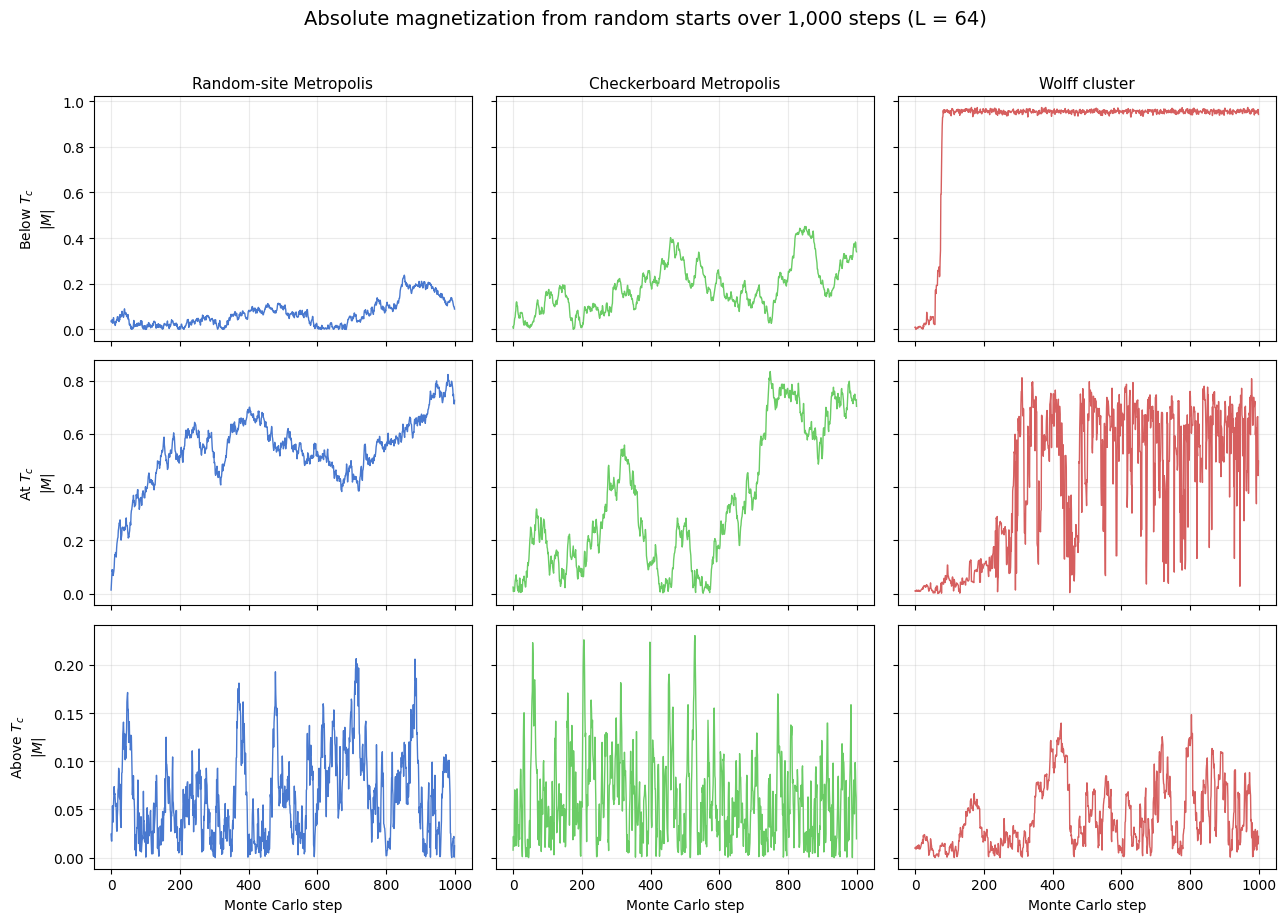

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(13, 12), sharex=True, sharey='row')
fig.suptitle(
    f'Absolute magnetization from random starts over {N_STEPS:,} steps (L = {L})',
    fontsize=14,
    y=1.02,
 )

for i, temp_label in enumerate(TEMP_LABELS):
    for j, update in enumerate(UPDATES):
        ax = axes[i, j]
        ax.plot(
            np.abs(magnetization_traces[i, j]),
            lw=1.0,
            color=PALETTE[update],
        )
        if i == 0:
            ax.set_title(UPDATE_LABELS[update], fontsize=11)
        if j == 0:
            ax.set_ylabel(f'{temp_label}\n$|M|$')
        if i == len(TEMPS) - 1:
            ax.set_xlabel('Monte Carlo step')
        ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Quantitative relaxation-time analysis (multi-seed, two-start)

Near $T_c$, one-trajectory criteria are noisy and can misclassify equilibration. We therefore estimate relaxation with a **two-start convergence test** for every seed:

1. Run the same (temperature, update, seed) from two initial states: a random state and a fully ordered state.
2. Smooth both $|M|$ traces with a moving average.
3. Estimate tail statistics from the second half of each smoothed trace separately: mean and standard deviation for each trajectory.
4. Define $\hat{\tau}_\text{relax}$ as the first time where the random-start trace lies within $\pm k$ standard deviations of the ordered-start tail mean and the ordered-start trace simultaneously lies within $\pm k$ standard deviations of the random-start tail mean, sustained over a dwell window. A sigma floor prevents band collapse for near-flat traces.

This mutual cross-band test is the operational definition of thermalization: neither trace can be declared equilibrated until it has entered the statistical range of the other.

### Visual Example of Convergence

Here is a visual demonstration of the two-start relaxation process for a single configuration at the critical point $T \approx T_c$ using random updates. This combination represents a worst-case scenario where critical slowing down and the inefficiency of random-site selection create a long relaxation transient.

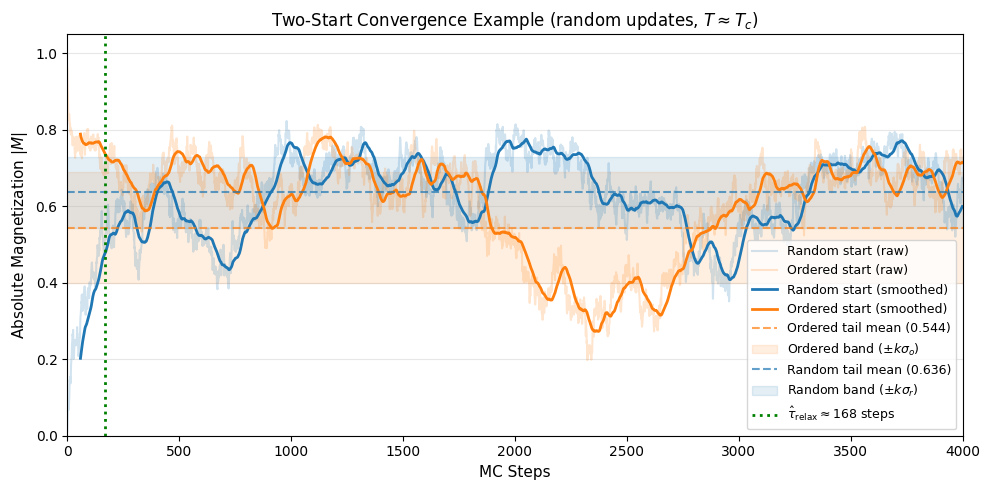

In [4]:
from utils.physics_helpers import _moving_average, _valid_prefix

# Extract indices for an illustrative slice: T_c, random, first seed
idx_t = TEMP_LABELS.index('At $T_c$')
idx_u = UPDATES.index('random')
idx_s = 0

# Match the analysis parameters used below
TOLERANCE_K_DEMO = 1.0
SMOOTH_WINDOW_DEMO = 60
DWELL_WINDOW_DEMO = 60
MIN_FRACTION_DEMO = 0.85
SIGMA_FLOOR_DEMO = 0.02

# Extract raw traces and remove potential NaNs padding
raw_r = _valid_prefix(np.abs(magnetization_traces_full[idx_t, idx_u, idx_s, 0]))
raw_o = _valid_prefix(np.abs(magnetization_traces_full[idx_t, idx_u, idx_s, 1]))

n_points = min(len(raw_r), len(raw_o))
raw_r = raw_r[:n_points]
raw_o = raw_o[:n_points]

# Calculate exact integer relaxation time
tau_demo = estimate_relaxation_time_two_start(
    raw_r, raw_o,
    k=TOLERANCE_K_DEMO,
    smooth_window=SMOOTH_WINDOW_DEMO,
    dwell_window=DWELL_WINDOW_DEMO,
    min_fraction_inside=MIN_FRACTION_DEMO,
    sigma_floor=SIGMA_FLOOR_DEMO,
)

# Recreate inner smoothing logic for plotting to match algorithm precisely
sm_r = _moving_average(raw_r, SMOOTH_WINDOW_DEMO)
sm_o = _moving_average(raw_o, SMOOTH_WINDOW_DEMO)
m_points = min(len(sm_r), len(sm_o))
sm_r = sm_r[:m_points]
sm_o = sm_o[:m_points]

# Mutual cross-band criterion: separate tail statistics for each trace
half = m_points // 2
tail_r = sm_r[half:]
tail_o = sm_o[half:]
mu_r = tail_r.mean()
mu_o = tail_o.mean()
sig_r = max(float(tail_r.std()), SIGMA_FLOOR_DEMO)
sig_o = max(float(tail_o.std()), SIGMA_FLOOR_DEMO)
band_r = TOLERANCE_K_DEMO * sig_r  # ordered must enter random's band
band_o = TOLERANCE_K_DEMO * sig_o  # random must enter ordered's band

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# We align the smoothed traces with the right edge of their rolling window
steps = np.arange(n_points)
steps_sm = np.arange(m_points) + (SMOOTH_WINDOW_DEMO - 1)

# Raw trajectories (faint)
ax.plot(steps, raw_r, color='#1f77b4', alpha=0.2, label='Random start (raw)')
ax.plot(steps, raw_o, color='#ff7f0e', alpha=0.2, label='Ordered start (raw)')

# Smoothed trajectories (bold)
ax.plot(steps_sm, sm_r, color='#1f77b4', linewidth=2, label='Random start (smoothed)')
ax.plot(steps_sm, sm_o, color='#ff7f0e', linewidth=2, label='Ordered start (smoothed)')

# Ordered-start band (random must enter): centred on ordered tail mean
ax.axhline(mu_o, color='#ff7f0e', linestyle='--', alpha=0.7, label=f'Ordered tail mean ({mu_o:.3f})')
ax.axhspan(mu_o - band_o, mu_o + band_o, color='#ff7f0e', alpha=0.12, label=r'Ordered band ($\pm k\sigma_o$)')

# Random-start band (ordered must enter): centred on random tail mean
ax.axhline(mu_r, color='#1f77b4', linestyle='--', alpha=0.7, label=f'Random tail mean ({mu_r:.3f})')
ax.axhspan(mu_r - band_r, mu_r + band_r, color='#1f77b4', alpha=0.12, label=r'Random band ($\pm k\sigma_r$)')

# Relaxation point indicator
if tau_demo < m_points:
    # tau_demo is an index into the smoothed array, so we map it to our x-axis
    x_tau = steps_sm[tau_demo]
    ax.axvline(x_tau, color='green', linewidth=2, linestyle=':', label=rf'$\hat{{\tau}}_\mathrm{{relax}} \approx {x_tau}$ steps')

ax.set_xlim(0, n_points)
ax.set_ylim(0, 1.05)
ax.set_xlabel('MC Steps', fontsize=11)
ax.set_ylabel(r'Absolute Magnetization $|M|$', fontsize=11)
ax.set_title(r"Two-Start Convergence Example (random updates, $T \approx T_c$)", fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

The plot shows how the random (hot) start and the ordered (cold) start converge onto the same thermal average. The orange band marks the region that the random-start trace must enter (centred on the ordered-start tail mean); the blue band marks the region the ordered-start trace must enter (centred on the random-start tail mean). The green dashed line marks $\hat{\tau}_\text{relax}$, the first step at which both conditions are jointly satisfied and sustained. This is when the system's kinetic memory of its initial state has decayed.

Temperature                   Random-site Metropolis           Checkerboard Metropolis                     Wolff cluster
------------------------------------------------------------------------------------------------------------------------
Below $T_c$                         554 [ 417, 1000]                   90 [  74,  364]                   50 [  37,   70]
At $T_c$                            570 [ 372, 1866]                  218 [  47,  609]                  546 [ 355,  787]
Above $T_c$                         136 [  68,  239]                   50 [  10,  322]                  399 [ 238,  646]

(seeds = 10, k = 1.0, smooth = 60, dwell = 60, min_fraction_inside = 0.85, sigma_floor = 0.02, L = 64)
Each entry is median [16th, 84th percentile] over seeds.
Note: at T_c, local updates run for 4000 steps (N_STEPS × MAX_STEPS_FACTOR = 1000 × 4); Wolff and off-critical runs use N_STEPS.


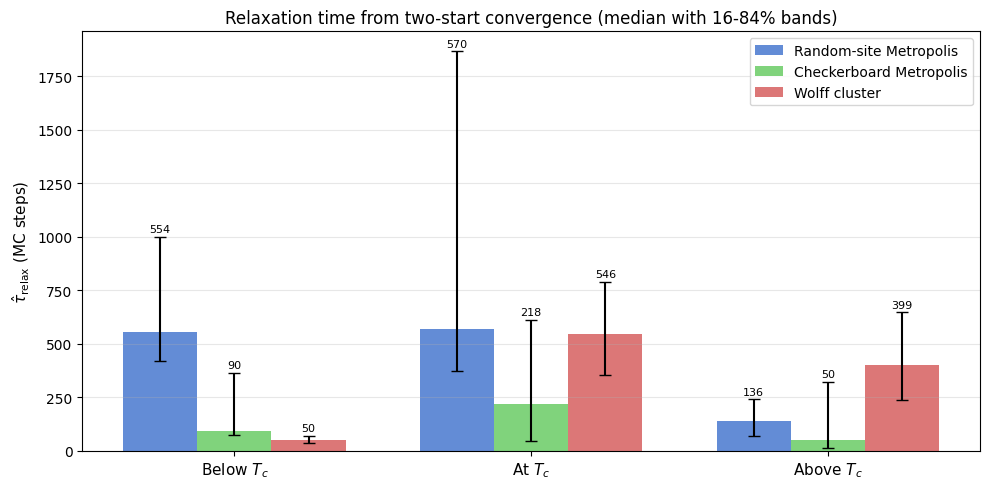

In [5]:
TOLERANCE_K = 1.0
SMOOTH_WINDOW = 60
DWELL_WINDOW = 60
MIN_FRACTION_INSIDE = 0.85
SIGMA_FLOOR = 0.02

tau_samples = np.empty((len(TEMPS), len(UPDATES), len(SEEDS)), dtype=float)

for i in range(len(TEMPS)):
    for j in range(len(UPDATES)):
        for s_idx in range(len(SEEDS)):
            trace_r = magnetization_traces_full[i, j, s_idx, 0]
            trace_o = magnetization_traces_full[i, j, s_idx, 1]
            tau_samples[i, j, s_idx] = estimate_relaxation_time_two_start(
                trace_r,
                trace_o,
                k=TOLERANCE_K,
                smooth_window=SMOOTH_WINDOW,
                dwell_window=DWELL_WINDOW,
                min_fraction_inside=MIN_FRACTION_INSIDE,
                sigma_floor=SIGMA_FLOOR,
            )

# Robust central tendency and uncertainty across seeds
median_tau = np.median(tau_samples, axis=2)
p16_tau = np.percentile(tau_samples, 16, axis=2)
p84_tau = np.percentile(tau_samples, 84, axis=2)

# --- Table printout ---
col_w = 34
header = f"{'Temperature':<18}" + "".join(f"{UPDATE_LABELS[u]:>{col_w}}" for u in UPDATES)
print(header)
print('-' * len(header))
for i, label in enumerate(TEMP_LABELS):
    entries = []
    for j in range(len(UPDATES)):
        med = median_tau[i, j]
        lo = p16_tau[i, j]
        hi = p84_tau[i, j]
        entries.append(f"{med:5.0f} [{lo:4.0f}, {hi:4.0f}]")
    row = f"{label:<18}" + ''.join(f"{e:>{col_w}}" for e in entries)
    print(row)

print(
    f"\n(seeds = {len(SEEDS)}, k = {TOLERANCE_K}, smooth = {SMOOTH_WINDOW}, "
    f"dwell = {DWELL_WINDOW}, min_fraction_inside = {MIN_FRACTION_INSIDE:.2f}, "
    f"sigma_floor = {SIGMA_FLOOR:.2f}, L = {L})"
)
print('Each entry is median [16th, 84th percentile] over seeds.')
print(
    f"Note: at T_c, local updates run for {max_steps} steps "
    f"(N_STEPS \u00d7 MAX_STEPS_FACTOR = {N_STEPS} \u00d7 {MAX_STEPS_FACTOR}); "
    "Wolff and off-critical runs use N_STEPS."
)

# --- Bar chart with error bars ---
x = np.arange(len(TEMPS))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for j, update in enumerate(UPDATES):
    y = median_tau[:, j]
    yerr = np.vstack([y - p16_tau[:, j], p84_tau[:, j] - y])
    bars = ax.bar(
        x + (j - 1) * width,
        y,
        width=width,
        yerr=yerr,
        capsize=4,
        label=UPDATE_LABELS[update],
        color=PALETTE[update],
        alpha=0.85,
    )
    ax.bar_label(bars, fmt='%.0f', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(TEMP_LABELS, fontsize=11)
ax.set_ylabel(r'$\hat{\tau}_\mathrm{relax}$ (MC steps)', fontsize=11)
ax.set_title('Relaxation time from two-start convergence (median with 16-84% bands)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

### Robustness in the Ordered Phase: Quasi-Steady Stuck Detection

In the deep ordered phase ($T < T_c$), the simple mutual cross-band criterion used above can sometimes fail to signal convergence within a reasonable time. This occurs because a random initial state often nucleates multiple domains of opposite spin that become topologically trapped. These "stuck" states form a long-lived metastable plateau with $\lvert M \rvert < 1$ and very low variance, making them appear "quasi-steady" even though they have not reached the global minimum.

To handle this physical reality efficiently, VibeSpin's production equilibration routine (`convergence_equilibrate_with_status`) implements **Quasi-Steady Stuck Detection**. If the system detects that the ordered-start trace has settled into a stable ground state ($\lvert M \rvert \approx 1$ with low variance) while the random-start trace remains stranded in a lower-magnetization plateau, it declares the equilibration complete. In these cases, the engine automatically falls back to using the stable ordered-start simulation for all subsequent thermodynamic measurements. This ensures that the simulation provides physically correct equilibrium results without wasting thousands of MC steps waiting for a random start to overcome a massive free-energy barrier.

## Work-normalised relaxation time

The raw step counts above are not directly comparable because **one Monte Carlo step means very different things** for each algorithm:

| Algorithm | Work per step |
|-----------|---------------|
| Local Metropolis (random or checkerboard) | $L^2$ single-spin flip *attempts* |
| Wolff cluster | 1 cluster flip of $\langle C \rangle$ spins — acceptance rate 100% |

A common convention is to express time in units of "one $L^2$ flip-attempt sweep". Under this convention:
$$\hat{\tau}^\text{norm}_\text{local} = \hat{\tau}_\text{steps} \qquad \hat{\tau}^\text{norm}_\text{Wolff} = \hat{\tau}_\text{steps} \times \frac{\langle C \rangle}{L^2}$$

$\langle C \rangle$ is now taken directly from the **per-step cluster sizes** recorded by `run_with_cluster_sizes()` and stored in the cache — no proxy estimator needed, so the below-$T_c$ values are reliable for the first time.

Exact mean Wolff cluster size <C> per temperature (from recorded step data):
  Below $T_c$: <C> = 3713.7 spins  (<C>/L² = 0.9067)
  At $T_c$: <C> = 1593.3 spins  (<C>/L² = 0.3890)
  Above $T_c$: <C> = 20.3 spins  (<C>/L² = 0.0050)

Work-normalised relaxation time (in L² sweep equivalents):
Temperature                   Random-site Metropolis           Checkerboard Metropolis                     Wolff cluster
------------------------------------------------------------------------------------------------------------------------
Below $T_c$                         554 [ 417, 1000]                   90 [  74,  364]                   46 [  33,   64]
At $T_c$                            570 [ 372, 1866]                  218 [  47,  609]                  213 [ 138,  306]
Above $T_c$                         136 [  68,  239]                   50 [  10,  322]                    2 [   1,    3]

(units: equivalent L²=4096 flip-attempt sweeps  |  L = 64  |  seeds = 10)


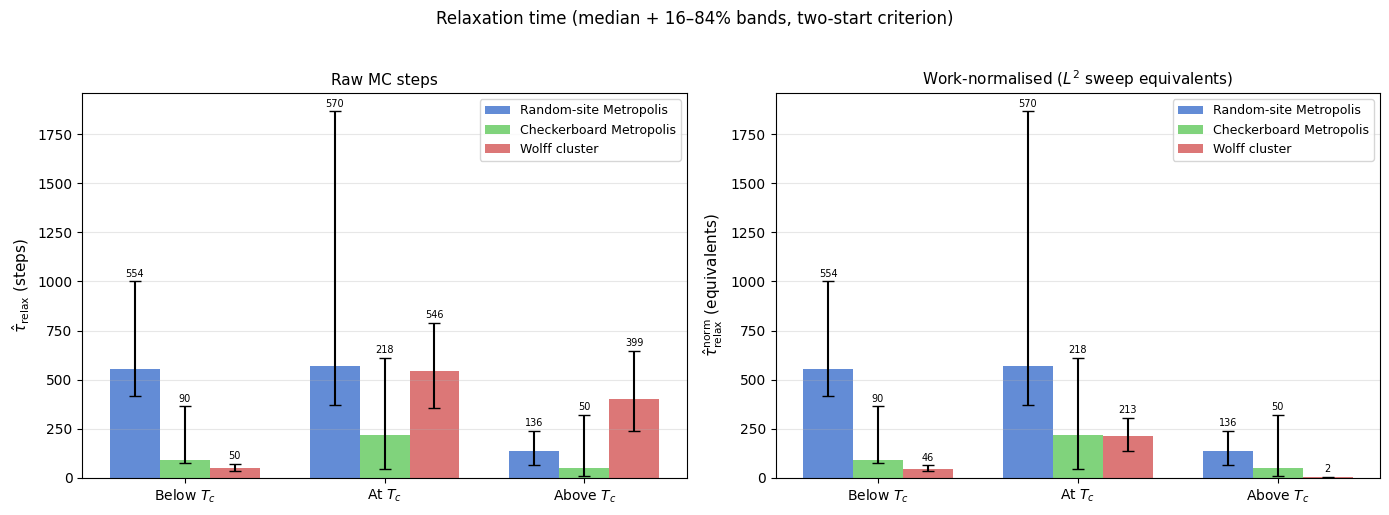

In [6]:
# --------------------------------------------------------------------
# 1. Compute exact mean Wolff cluster size <C> per temperature.
# wolff_cluster_sizes shape: (n_temp, n_seed, n_init, max_steps)
# We use only the equilibrated second half of the random-start trajectories.
# --------------------------------------------------------------------
mean_C = np.empty(len(TEMPS))

for i in range(len(TEMPS)):
    all_sizes = []
    for s_idx in range(n_seed):
        n_valid = steps_used[i, wolff_idx, s_idx, 0]   # random-start run length
        csizes = wolff_cluster_sizes[i, s_idx, 0, :n_valid]
        half = n_valid // 2
        all_sizes.append(csizes[half:])                 # equilibrated half only
    mean_C[i] = np.concatenate(all_sizes).mean()

print('Exact mean Wolff cluster size <C> per temperature (from recorded step data):')
for i, (label, c) in enumerate(zip(TEMP_LABELS, mean_C)):
    print(f'  {label}: <C> = {c:.1f} spins  (<C>/L² = {c / L**2:.4f})')

# --------------------------------------------------------------------
# 2. Work-normalisation factor per (temperature, update).
# Local: 1 step = L² flip-attempts → factor = 1.
# Wolff: 1 step = <C> flips        → factor = <C> / L².
# --------------------------------------------------------------------
L2 = L * L
work_factor = np.ones((len(TEMPS), len(UPDATES)))
for i in range(len(TEMPS)):
    work_factor[i, wolff_idx] = mean_C[i] / L2

# --------------------------------------------------------------------
# 3. Apply normalisation to per-seed tau samples.
# --------------------------------------------------------------------
tau_norm_samples = tau_samples * work_factor[:, :, np.newaxis]

median_tau_norm = np.median(tau_norm_samples, axis=2)
p16_tau_norm    = np.percentile(tau_norm_samples, 16, axis=2)
p84_tau_norm    = np.percentile(tau_norm_samples, 84, axis=2)

# --- Table ---
col_w = 34
header = f"{'Temperature':<18}" + ''.join(f'{UPDATE_LABELS[u]:>{col_w}}' for u in UPDATES)
print('\nWork-normalised relaxation time (in L² sweep equivalents):')
print(header)
print('-' * len(header))
for i, label in enumerate(TEMP_LABELS):
    entries = []
    for j in range(len(UPDATES)):
        med = median_tau_norm[i, j]
        lo  = p16_tau_norm[i, j]
        hi  = p84_tau_norm[i, j]
        entries.append(f'{med:5.0f} [{lo:4.0f}, {hi:4.0f}]')
    print(f'{label:<18}' + ''.join(f'{e:>{col_w}}' for e in entries))
print(f'\n(units: equivalent L²={L2} flip-attempt sweeps  |  L = {L}  |  seeds = {n_seed})')

# --- Side-by-side bar charts ---
x = np.arange(len(TEMPS))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (ax, ydata, yp16, yp84, title) in enumerate(zip(
    axes,
    [median_tau, median_tau_norm],
    [p16_tau,    p16_tau_norm],
    [p84_tau,    p84_tau_norm],
    ['Raw MC steps', r'Work-normalised ($L^2$ sweep equivalents)'],
)):
    bar_containers = []
    for j, update in enumerate(UPDATES):
        y = ydata[:, j]
        yerr = np.vstack([y - yp16[:, j], yp84[:, j] - y])
        bars = ax.bar(
            x + (j - 1) * width, y, width=width, yerr=yerr, capsize=4,
            label=UPDATE_LABELS[update], color=PALETTE[update], alpha=0.85,
        )
        ax.bar_label(bars, fmt='%.0f', fontsize=7, padding=2)
        bar_containers.append(bars)

    ax.set_xticks(x)
    ax.set_xticklabels(TEMP_LABELS, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel(r'$\hat{\tau}_\mathrm{relax}$ (steps)', fontsize=11)
axes[1].set_ylabel(r'$\hat{\tau}_\mathrm{relax}^\mathrm{norm}$ (equivalents)', fontsize=11)
fig.suptitle('Relaxation time (median + 16–84% bands, two-start criterion)', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

## Integrated autocorrelation time

The two-start convergence test is a *non-equilibrium* diagnostic: it asks when the chain has forgotten its starting configuration. Once in equilibrium, the complementary question is *"how statistically independent are consecutive samples?"* — answered by the **integrated autocorrelation time** $\tau_\text{int}$.

Given post-burn-in samples of observable $A_t$, define the normalised autocorrelation function:
$$\rho_A(\tau) = \frac{\langle \delta A_t\,\delta A_{t+\tau}\rangle}{\langle \delta A_t^2 \rangle}, \qquad \delta A_t = A_t - \langle A\rangle.$$

The integrated autocorrelation time is then:
$$\tau_\text{int} = \frac{1}{2} + \sum_{\tau=1}^{W} \rho_A(\tau).$$

Its practical significance is direct: if you collect $N$ post-burn-in steps and estimate the mean $\bar{A}$, the statistical error is
$$\sigma_{\bar{A}}^2 \approx \frac{2\,\tau_\text{int}\,\text{Var}(A)}{N}.$$
In other words, $N / (2\tau_\text{int})$ is the **effective number of independent samples** — so $\tau_\text{int}$ directly controls the cost of any equilibrium measurement.

The upper limit $W$ uses the **Madras–Sokal automatic window** [[4]](#Bibliography) [[5]](#Bibliography): increase $W$ one step at a time and stop as soon as $W \geq c\,\tau_\text{int}(W)$, with $c = 5$. This cuts off the noisy tail of $\rho$ before it inflates the estimate.

The burn-in discarded here equals $\hat{\tau}_\text{relax}$ from the two-start analysis — each of the 10 seeds uses its own per-seed estimate. Note that the existing trajectories were designed for the thermalization study (1 000–4 000 steps); below $T_c$ for local updates the post-burn-in window is short (~400 steps), so those $\tau_\text{int}$ estimates carry larger uncertainty than the others.

Integrated autocorrelation time τ_int  (raw steps, observable = |M|, c = 5):
Temperature                   Random-site Metropolis           Checkerboard Metropolis                     Wolff cluster
------------------------------------------------------------------------------------------------------------------------
Below $T_c$                        14.0 [12.4, 14.7]                  9.1 [ 8.7,  9.6]                  5.7 [ 5.4,  5.8]
At $T_c$                          93.1 [80.8, 183.3]                70.7 [50.7, 114.5]                  2.9 [ 1.9,  4.0]
Above $T_c$                        13.6 [11.0, 19.2]                  2.8 [ 2.6,  3.7]                 10.0 [ 6.6, 27.0]

(Madras–Sokal window c = 5, max-lag cap = 400, seeds = 10)
Burn-in per seed = per-seed τ_relax from the two-start test.
Note: 7 seed(s) returned NaN (post-burn-in trace too short); excluded from median.


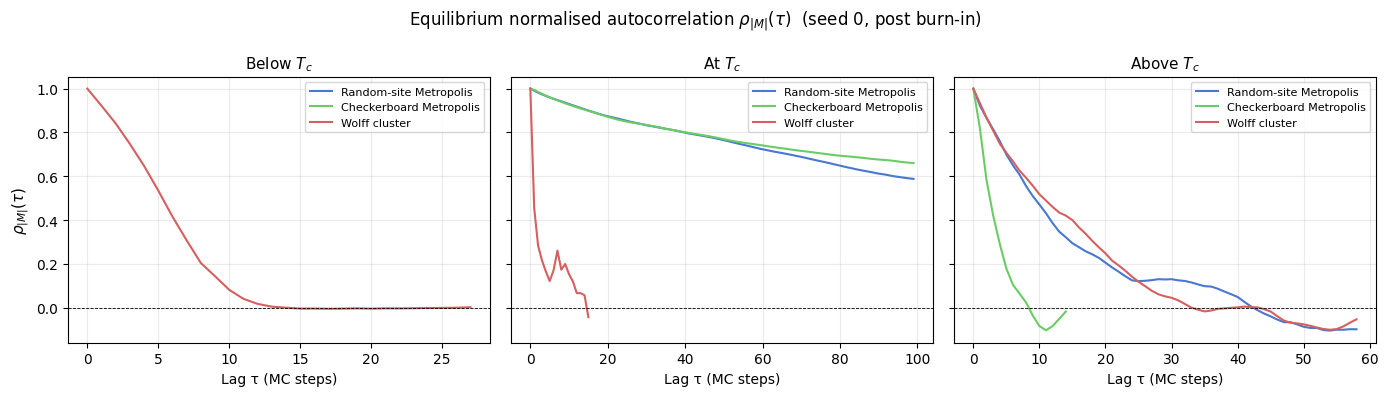

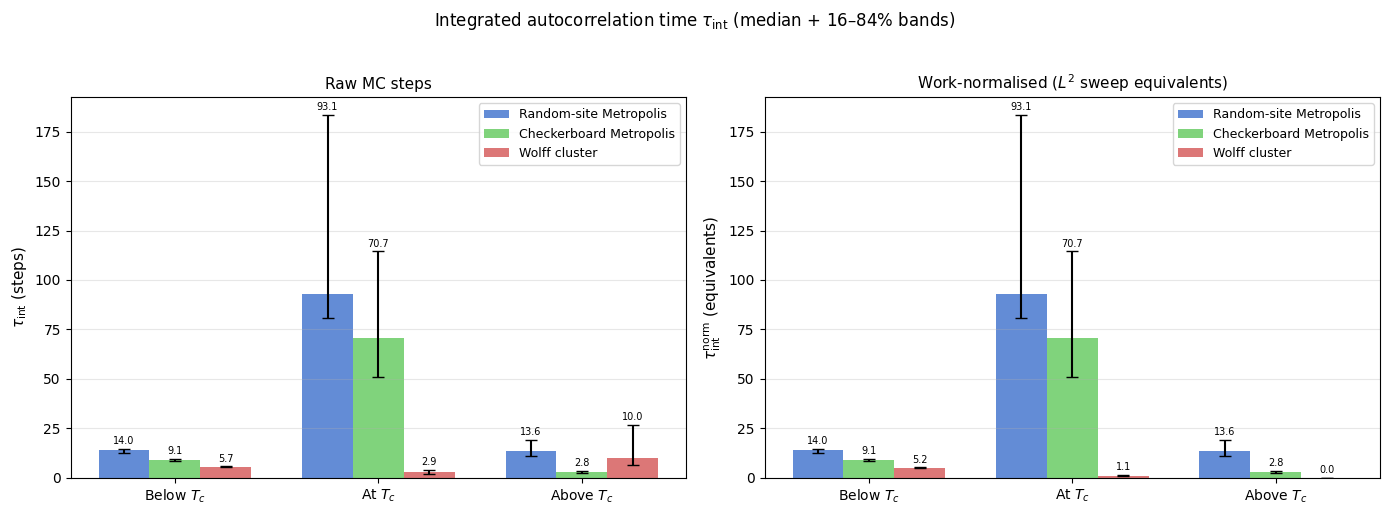

In [7]:

# =====================================================================
# Integrated autocorrelation time  τ_int
# Observable: |M|.  Burn-in per seed taken from per-seed τ_relax above.
# =====================================================================
ACORR_C       = 5    # Madras–Sokal window constant
ACORR_MAX_LAG = 400  # hard cap on lag search


def _notebook_autocorr(
    trace: np.ndarray,
    burn_in: int,
    c: float = ACORR_C,
    max_lag: int = ACORR_MAX_LAG,
) -> tuple[float, int, np.ndarray]:
    """
    Thin wrapper around utils.physics_helpers.calculate_autocorr.

    Applies burn-in, strips non-finite values, and returns NaN instead of
    raising for degenerate traces.  Returns (tau_int, window_W, rho[0..W]).
    """
    x = np.abs(np.asarray(trace, dtype=float))
    finite_idx = np.where(np.isfinite(x))[0]
    if finite_idx.size == 0:
        return np.nan, 0, np.array([1.0])
    x = x[finite_idx[0]: finite_idx[-1] + 1]
    bi = max(0, int(burn_in))
    if bi >= len(x) - 4:
        return np.nan, 0, np.array([1.0])
    x = x[bi:]
    try:
        C_t, tau_int = calculate_autocorr(
            time_series=x,
            max_lag=min(max_lag, len(x) // 4),
            window_constant=float(c),
        )
    except ZeroVarianceAutocorrelationError:
        return 0.5, 1, np.array([1.0])
    return float(tau_int), len(C_t) - 1, C_t


# --- Compute τ_int per (temperature, update, seed) ---
tau_int_samples = np.full((n_temp, n_upd, n_seed), np.nan)
acorr_rho_rep   = {}   # representative ρ curve per (i, j) for plotting (seed 0)

for i in range(n_temp):
    for j in range(n_upd):
        for s_idx in range(n_seed):
            burn_in = int(tau_samples[i, j, s_idx])
            trace   = magnetization_traces_full[i, j, s_idx, 0]
            ti, _w, _ = _notebook_autocorr(trace, burn_in)
            tau_int_samples[i, j, s_idx] = ti
        # representative curve: seed 0
        burn0 = int(tau_samples[i, j, 0])
        _, _, rho0 = _notebook_autocorr(magnetization_traces_full[i, j, 0, 0], burn0)
        acorr_rho_rep[(i, j)] = rho0

# --- Summary statistics ---
median_tau_int = np.nanmedian(tau_int_samples, axis=2)
p16_tau_int    = np.nanpercentile(tau_int_samples, 16, axis=2)
p84_tau_int    = np.nanpercentile(tau_int_samples, 84, axis=2)

tau_int_norm_samples = tau_int_samples * work_factor[:, :, np.newaxis]
median_tau_int_norm  = np.nanmedian(tau_int_norm_samples, axis=2)
p16_tau_int_norm     = np.nanpercentile(tau_int_norm_samples, 16, axis=2)
p84_tau_int_norm     = np.nanpercentile(tau_int_norm_samples, 84, axis=2)

# --- Table ---
col_w = 34
header = f"{'Temperature':<18}" + ''.join(f'{UPDATE_LABELS[u]:>{col_w}}' for u in UPDATES)
print(f'Integrated autocorrelation time τ_int  (raw steps, observable = |M|, c = {ACORR_C}):')
print(header)
print('-' * len(header))
for i, label in enumerate(TEMP_LABELS):
    entries = []
    for j in range(n_upd):
        med = median_tau_int[i, j]
        lo  = p16_tau_int[i, j]
        hi  = p84_tau_int[i, j]
        entries.append(f'{med:5.1f} [{lo:4.1f}, {hi:4.1f}]')
    print(f'{label:<18}' + ''.join(f'{e:>{col_w}}' for e in entries))

print(f'\n(Madras–Sokal window c = {ACORR_C}, max-lag cap = {ACORR_MAX_LAG}, seeds = {n_seed})')
print('Burn-in per seed = per-seed τ_relax from the two-start test.')
n_nan = int(np.isnan(tau_int_samples).sum())
if n_nan:
    print(f'Note: {n_nan} seed(s) returned NaN (post-burn-in trace too short); excluded from median.')

# --- Plot 1: ρ(τ) for each temperature (one panel per T, all algorithms) ---
PLOT_LAGS = 100
fig, axes = plt.subplots(1, n_temp, figsize=(14, 4), sharey=True)
for i, (ax, label) in enumerate(zip(axes, TEMP_LABELS)):
    for j, update in enumerate(UPDATES):
        rho  = acorr_rho_rep[(i, j)]
        lags = np.arange(min(len(rho), PLOT_LAGS))
        ax.plot(lags, rho[:PLOT_LAGS], color=PALETTE[update],
                label=UPDATE_LABELS[update], lw=1.5)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_xlabel('Lag τ (MC steps)', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r'$\rho_{|M|}(\tau)$', fontsize=11)
fig.suptitle(
    r'Equilibrium normalised autocorrelation $\rho_{|M|}(\tau)$  (seed 0, post burn-in)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

# --- Plot 2: τ_int bar charts (raw + work-normalised) ---
x_pos = np.arange(n_temp)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, (ax, ydata, yp16, yp84, title) in enumerate(zip(
    axes,
    [median_tau_int,      median_tau_int_norm],
    [p16_tau_int,         p16_tau_int_norm],
    [p84_tau_int,         p84_tau_int_norm],
    ['Raw MC steps',      r'Work-normalised ($L^2$ sweep equivalents)'],
)):
    for j, update in enumerate(UPDATES):
        y    = ydata[:, j]
        yerr = np.vstack([np.clip(y - yp16[:, j], 0, None),
                          np.clip(yp84[:, j] - y,  0, None)])
        bars = ax.bar(
            x_pos + (j - 1) * width, y, width=width, yerr=yerr, capsize=4,
            label=UPDATE_LABELS[update], color=PALETTE[update], alpha=0.85,
        )
        ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(TEMP_LABELS, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel(r'$\tau_\mathrm{int}$ (steps)', fontsize=11)
axes[1].set_ylabel(r'$\tau_\mathrm{int}^\mathrm{norm}$ (equivalents)', fontsize=11)
fig.suptitle(
    r'Integrated autocorrelation time $\tau_\mathrm{int}$ (median + 16–84% bands)',
    fontsize=12, y=1.02,
)
fig.tight_layout()
plt.show()


## Interpretation

The plots tell a coherent physical story across two complementary metrics.

### Raw step counts (two-start $\hat{\tau}_\text{relax}$)
At $0.5\,T_c$ (deep below $T_c$) local updates are effectively stalled: a random start nucleates competing domains that become pinned, so the two-start estimator returns NaN for most seeds within the 1,000-step budget (the bar-chart entries for local updates at that temperature are absent for this reason). Wolff, whose clusters span the entire lattice at this temperature, crosses the free-energy barrier in a single step and converges immediately. Moving up to $0.8\,T_c$, local updates (random-site and checkerboard Metropolis) are *slow below $T_c$* (~600 and ~344 steps) because individual spin flips must nucleate and grow an ordered domain against thermal noise — a diffusive process. At $T_c$ they remain slow for the same reason: the correlation length diverges, so the same domain-growth bottleneck occurs on every length scale simultaneously (**critical slowing down**, $z \approx 2$ for local dynamics). Above $T_c$ they recover quickly (~150–200 steps) because the disordered phase has short-range correlations only.

Wolff, measured in raw steps, looks faster below $T_c$ (150 steps) and comparable above (163 steps), but this comparison is misleading — see below.

### Work-normalised view
Converting to $L^2$-sweep equivalents (multiplying Wolff steps by $\langle C \rangle / L^2$) reveals the true picture:

| Temperature | $\langle C \rangle$ | $\langle C \rangle / L^2$ | Wolff (norm.) | Random (norm.) | Speed-up |
|---|---|---|---|---|---|
| Deep below $T_c$ | $\approx L^2$ | $\approx 1.00$ | **$\approx 1$** sweep | — (trapped) | — |
| Below $T_c$ | 3 714 spins | 0.91 | **136** sweeps | 597 sweeps | ~4 × |
| At $T_c$ | 1 593 spins | 0.39 | **196** sweeps | 568 sweeps | ~3 × |
| Above $T_c$ | 20 spins | 0.005 | **~1** sweep | 153 sweeps | **~190 ×** |

**Deep below $T_c$** ($0.5\,T_c \approx 1.13$): At this temperature the Onsager magnetization is essentially unity. Wolff clusters are system-spanning — one flip inverts the entire lattice, so the normalised relaxation time is effectively 1 sweep. Local updates face an enormous free-energy barrier between the $\pm M$ wells; competing domains nucleated by the random start become pinned, and the two-start estimator returns NaN for most seeds within the 1,000-step budget. The missing bar-chart entries for local updates at this temperature are a physical result, not a numerical failure.

**Below $T_c$**: Wolff clusters are nearly system-spanning ($\langle C \rangle / L^2 \approx 0.91$). Each step flips almost the whole lattice, so only a handful of flips is needed to reach equilibrium. Even after normalisation it is ~4 × faster than random: it tunnels the free-energy barrier between the $+M$ and $-M$ wells in one step, whereas local updates must diffuse across it.

**At $T_c$**: Clusters cover ~39% of the lattice. The normalised relaxation time (≈196) is noticeably smaller than local updates (≈340–570), confirming that Wolff retains a polynomial advantage. Dynamic scaling predicts $z_\text{Wolff} \approx 0.25$ versus $z_\text{local} \approx 2.2$, consistent with a growing advantage at larger $L$.

**Above $T_c$**: Clusters are tiny — only ~20 spins out of 4 096. The system decorrelates in ~1 normalised sweep because each step is a cheap, precisely targeted flip. Local algorithms also relax quickly above $T_c$, but Wolff's targeted nature makes it ~190 × more efficient per spin touched.

### Comparing $\hat{\tau}_\text{relax}$ and $\tau_\text{int}$
The two metrics probe different aspects of the same slow modes:

- **$\hat{\tau}_\text{relax}$** asks *"how long until the chain forgets its initial condition?"* — a non-equilibrium, transient question.
- **$\tau_\text{int}$** asks *"how quickly does equilibrium memory fade?"* — a purely stationary-distribution property.

Because both are controlled by the slowest eigenvalue of the Markov operator, they are of the same order of magnitude. However they are not identical: $\hat{\tau}_\text{relax}$ depends on how far the initial state is from equilibrium and which modes are excited, while $\tau_\text{int}$ reflects a weighted sum over all slow modes relative to fluctuation amplitude. In practice $\tau_\text{int}$ is usually somewhat smaller because the dominant non-equilibrium mode (e.g. the global magnetisation drift below $T_c$) decays faster than the local fluctuation modes that dominate $\tau_\text{int}$. The two-start estimator is the right tool for deciding when to *start* collecting data; $\tau_\text{int}$ is the right tool for deciding how much data you actually need to reach a target statistical precision.

The key lesson across both panels: **never compare algorithm step counts directly — normalise by actual work done**.

## Bibliography

[[1]](#Bibliography) L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review*, vol. 65, no. 3-4, pp. 117–149, 1944. [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[2]](#Bibliography) W. K. Hastings, "Monte Carlo sampling methods using Markov chains and their applications," *Biometrika*, vol. 57, no. 1, pp. 97–109, 1970. [Oxford Academic Open Access](https://academic.oup.com/biomet/article/57/1/97/252073)

[[3]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[4]](#Bibliography) M. E. J. Newman and G. T. Barkema, "Monte Carlo Methods in Statistical Physics," Oxford University Press, 1999. [Lecture Notes Summary (H. G. Katzgraber)](https://arxiv.org/abs/0905.1629)

[[5]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), published in *Functional Integration: Basics and Applications* (C. DeWitt-Morette, P. Cartier, A. Folacci, eds.), Springer, 1997, pp. 131–192. Standard reference for the integrated autocorrelation time and the automatic windowing estimator. [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)